# Raw signal verification — HPPC / ConstPower / PeakPower / GITT

Plots full time-series voltage, current, power and **OCV-anchored coulomb-counted SOC** for each test directly from the CSVs. Use these plots to **see** the actual probe structure and verify (or correct) the claims in the lab test report:

1. **HPPC**: only 9 probe groups at SOC ~0.97–1.00, then one big SOC-step discharge — *no probes at every 10 % SOC*
2. **ConstantPower**: 3 × discharge at 90 W and 3 × charge at 180 W (six pulses total) — *no 270 W pulses*
3. **PeakPower**: high-current peak pulses only at SOC ~0.92–0.97 (and a different mid-SOC band for cell 0008)
4. **GITT**: per-cell SOC coverage

## SOC method

For each test file we

1. find the **first significant rest segment** (|I| < 0.5 A and duration ≥ 5 s),
2. read the *rest-end voltage* (settled OCV),
3. look that voltage up in the project's `LFP_OCV_SOC_Table.xlsx` (101 rows, 1 % SOC steps) to get **start_soc**,
4. then forward-coulomb-count from there:  SOC(t) = start_soc + ∫ I dt / Q_nom,
5. and clip to [0, 1].

This replaces the earlier crude `start_soc = 0 or 1` hardcoded assumption and fixes the GITT-overshoot-above-1.0 issue. **Caveat:** if the file's first rest sits on the LFP plateau (~3.31 V), the V→SOC lookup is ambiguous and the anchor is unreliable in that 5–90 % SOC band — but the table being linearly monotonic from 2.5 V → 3.65 V here gives a single mapping by construction.

In [1]:
from __future__ import annotations
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT.parent / 'CLAUDE.md').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_test

Q_NOM = 105.0  # Ah, datasheet
CELL_PROBE = '0005'
COHORT = ['0005', '0006', '0007', '0008']

# ── Load OCV→SOC lookup table ────────────────────────────────────────
_ocv_table = pd.read_excel(Path('LFP_OCV_SOC_Table.xlsx'), sheet_name='OCV_SOC_LFP')
_ocv_table = _ocv_table.sort_values('OCV (V)').reset_index(drop=True)
_OCV_V = _ocv_table['OCV (V)'].to_numpy(dtype=float)
_SOC_FRAC = _ocv_table['SOC (%)'].to_numpy(dtype=float) / 100.0

def soc_from_ocv(v: float) -> float:
    """Look up SOC fraction from a settled-rest voltage via the LFP OCV-SOC table.

    Clips to the table range; for V outside [V_min, V_max] returns the endpoint
    SOC. Linear interpolation between rows.
    """
    return float(np.interp(v, _OCV_V, _SOC_FRAC))

def first_rest_end_voltage(df: pd.DataFrame,
                            min_dur_s: float = 5.0,
                            max_I_A: float = 0.5) -> tuple[float, float] | None:
    """Find the first sustained rest (|I| < max_I_A for >= min_dur_s) and
    return (rest_end_voltage, rest_end_time_s). Returns None if no rest qualifies.
    """
    d = df.sort_values('time').reset_index(drop=True)
    is_rest = d['current'].abs() < max_I_A
    d['_run'] = (is_rest != is_rest.shift()).cumsum()
    for run_id, g in d.groupby('_run'):
        if not is_rest.loc[g.index].iloc[0]:
            continue
        if (g['time'].iloc[-1] - g['time'].iloc[0]) < min_dur_s:
            continue
        return float(g['voltage'].iloc[-1]), float(g['time'].iloc[-1])
    return None


def add_soc_axis_anchored(df: pd.DataFrame,
                            q_nominal_ah: float = Q_NOM,
                            verbose: bool = False) -> tuple[pd.Series, dict]:
    """Coulomb-count SOC anchored at the first rest segment's end voltage,
    mapped via the global LFP OCV-SOC table. Returns (soc_series, meta).
    """
    anchor = first_rest_end_voltage(df)
    if anchor is None:
        # Fallback: use the file's first voltage as the OCV anchor
        v_anchor = float(df['voltage'].iloc[0])
        t_anchor = float(df['time'].iloc[0])
        anchor_kind = 'first_row_fallback'
    else:
        v_anchor, t_anchor = anchor
        anchor_kind = 'first_rest'
    start_soc = soc_from_ocv(v_anchor)

    t = df['time'].to_numpy(dtype=float)
    i = df['current'].to_numpy(dtype=float)
    # Coulomb count *forward from t_anchor*. For t < t_anchor we back-propagate.
    dt = np.diff(t, prepend=t[0])
    cumQ = np.cumsum(i * dt) / 3600.0  # Ah, signed
    cumQ_at_anchor = float(np.interp(t_anchor, t, cumQ))
    soc = start_soc + (cumQ - cumQ_at_anchor) / q_nominal_ah
    soc = np.clip(soc, 0.0, 1.0)
    meta = {
        'anchor_kind': anchor_kind,
        'anchor_t_s': t_anchor,
        'anchor_voltage_V': v_anchor,
        'start_soc': start_soc,
        'q_nominal_Ah': q_nominal_ah,
    }
    if verbose:
        print(f"  anchor: V={v_anchor:.4f}V at t={t_anchor:.0f}s → SOC={start_soc:.3f} ({anchor_kind})")
    return pd.Series(soc, index=df.index, name='SOC_est'), meta


print('Project root:', ROOT)
print(f'Loaded OCV-SOC table: {len(_ocv_table)} rows, V range [{_OCV_V.min():.3f}, {_OCV_V.max():.3f}]')
print(f'Sanity check — soc_from_ocv: V=2.5 → SOC={soc_from_ocv(2.5):.3f}, '
       f'V=3.31 → SOC={soc_from_ocv(3.31):.3f}, V=3.65 → SOC={soc_from_ocv(3.65):.3f}')
print('Probe cell  :', CELL_PROBE)
print('Cohort      :', COHORT)

Project root: /home/hj/Desktop/PINNs
Loaded OCV-SOC table: 101 rows, V range [2.500, 3.650]
Sanity check — soc_from_ocv: V=2.5 → SOC=0.000, V=3.31 → SOC=0.637, V=3.65 → SOC=1.000
Probe cell  : 0005
Cohort      : ['0005', '0006', '0007', '0008']


/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. HPPC raw signals

Plot V(t), I(t), and the coulomb-counted SOC(t) for the entire HPPC file. The 9 probe groups (52.5 A discharge / 39 A charge probes at 30 s) should cluster at the very top of the SOC trace, and we expect to see only ONE large SOC-step discharge after them — not 9 distinct probe groups distributed across SOC.

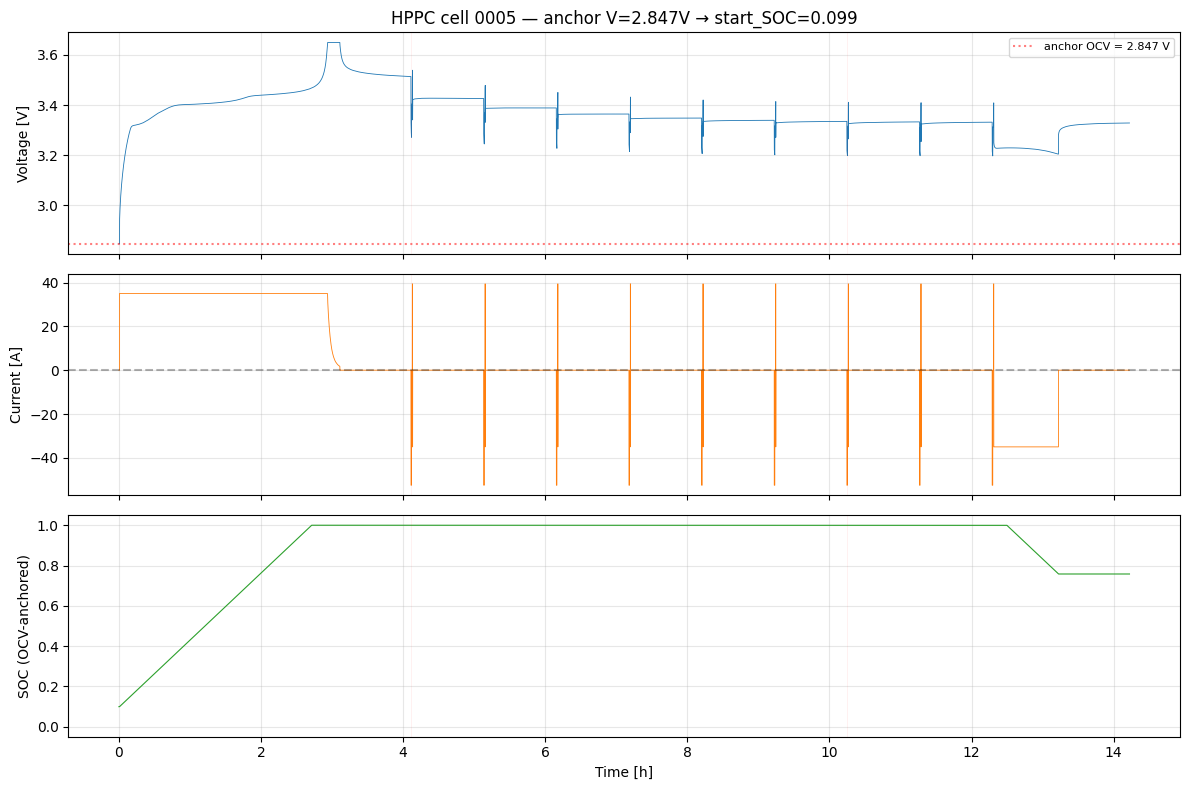

  SOC range covered by probes (|I| > 45 A): 1.000 → 1.000
  end-of-file SOC: 0.758


In [2]:
def plot_hppc_full(cell_id: str):
    df = load_test('HPPC', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    soc, meta = add_soc_axis_anchored(df, verbose=False)
    t_h = df['time'].values / 3600.0

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(t_h, df['voltage'].values, lw=0.6, color='C0')
    axes[0].set(ylabel='Voltage [V]',
                title=f'HPPC cell {cell_id} — anchor V={meta["anchor_voltage_V"]:.3f}V → start_SOC={meta["start_soc"]:.3f}')
    axes[0].axhline(meta['anchor_voltage_V'], ls=':', color='red', alpha=0.5,
                    label=f'anchor OCV = {meta["anchor_voltage_V"]:.3f} V')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_h, df['current'].values, lw=0.6, color='C1')
    axes[1].set(ylabel='Current [A]')
    axes[1].axhline(0, ls='--', color='black', alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(t_h, soc, lw=0.8, color='C2')
    axes[2].set(ylabel='SOC (OCV-anchored)', xlabel='Time [h]', ylim=(-0.05, 1.05))
    axes[2].grid(True, alpha=0.3)
    probe_mask = df['current'].abs() > 45
    if probe_mask.any():
        for ax in axes:
            for tm in t_h[probe_mask][::200]:
                ax.axvline(tm, color='red', alpha=0.08, lw=0.5)
    fig.tight_layout()
    plt.show()

    # Numeric verification: SOC band of the probe pulses
    df['SOC'] = soc.values
    probe = df[df['current'].abs() > 45]
    if not probe.empty:
        print(f'  SOC range covered by probes (|I| > 45 A): {probe["SOC"].min():.3f} → {probe["SOC"].max():.3f}')
    print(f'  end-of-file SOC: {soc.iloc[-1]:.3f}')

plot_hppc_full(CELL_PROBE)

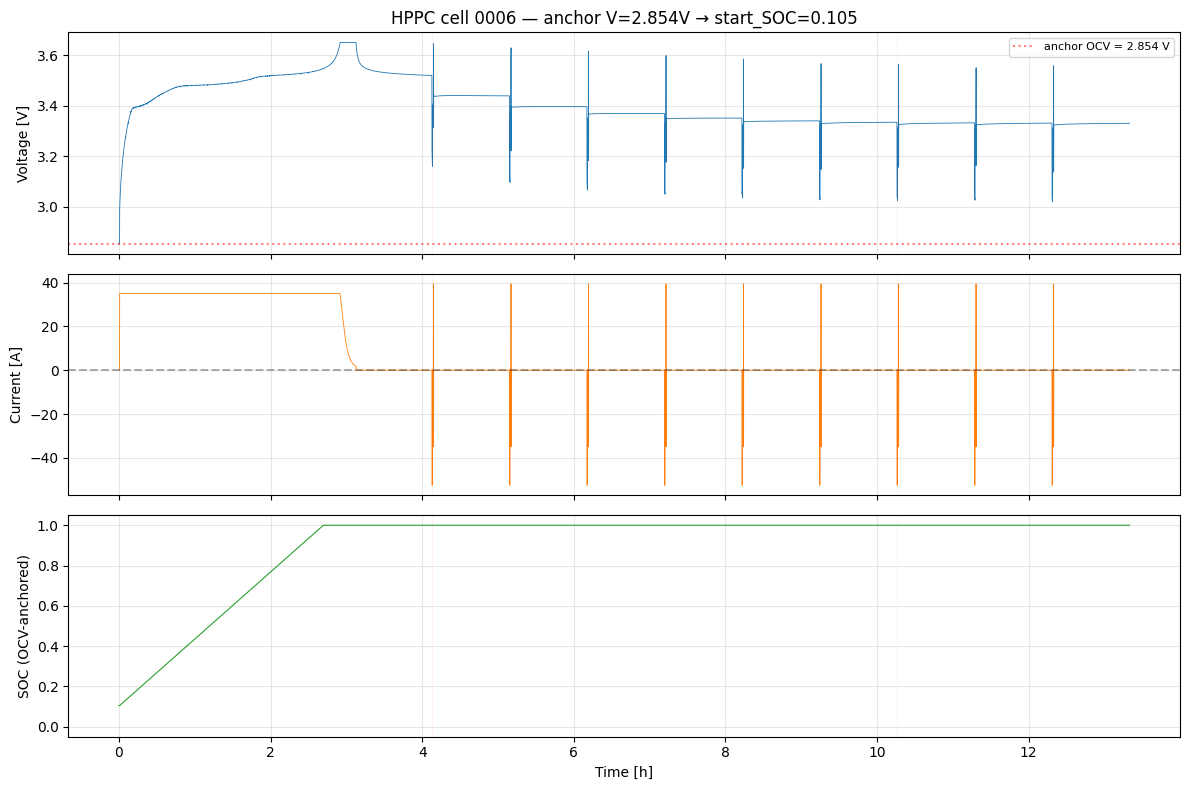

  SOC range covered by probes (|I| > 45 A): 1.000 → 1.000
  end-of-file SOC: 1.000


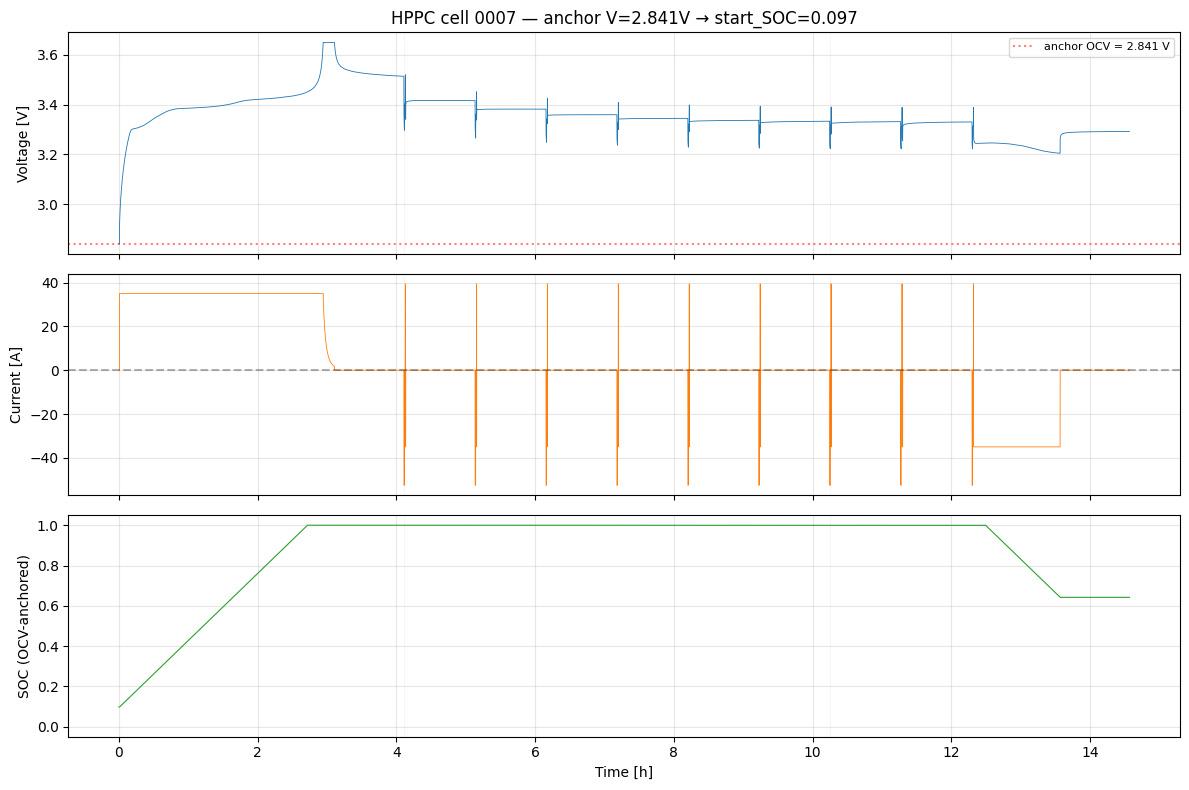

  SOC range covered by probes (|I| > 45 A): 1.000 → 1.000
  end-of-file SOC: 0.642


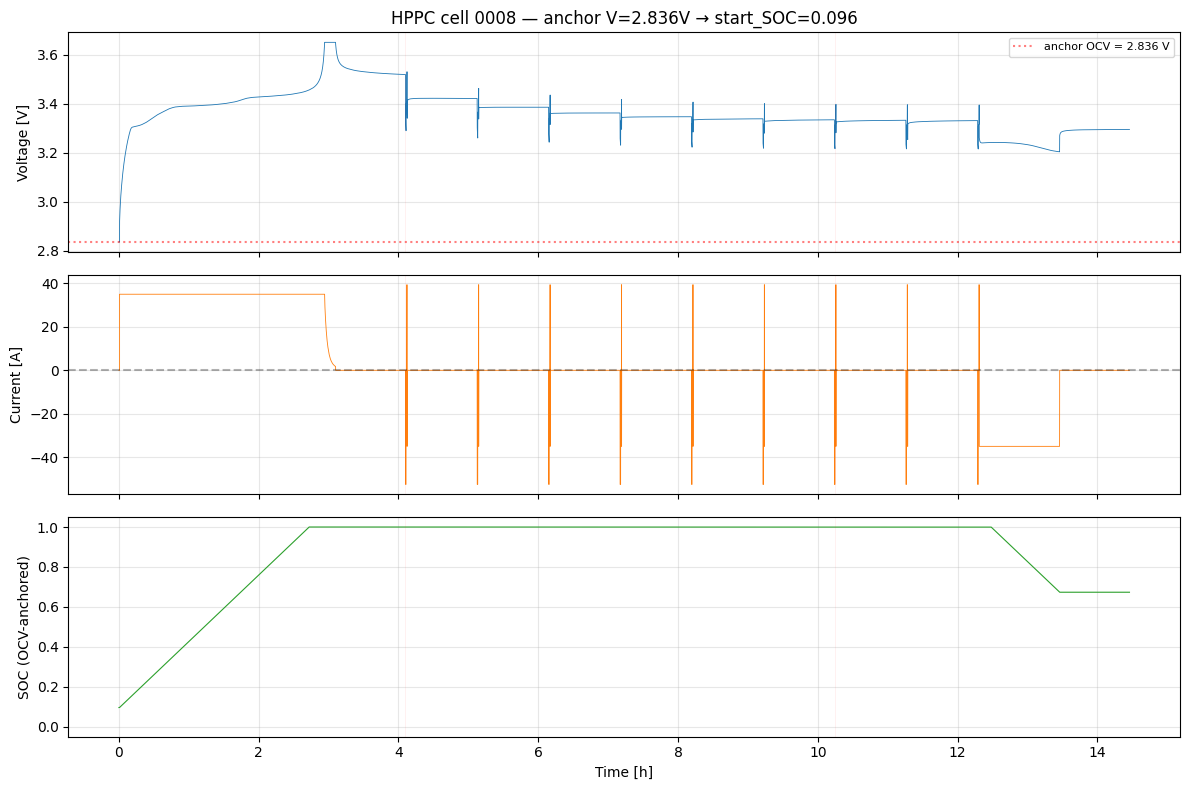

  SOC range covered by probes (|I| > 45 A): 1.000 → 1.000
  end-of-file SOC: 0.673


In [3]:
# Same plot for the other cohort cells to confirm pattern
for cid in ['0006', '0007', '0008']:
    plot_hppc_full(cid)

### 1b. HPPC SOC verification — per-pulse OCV vs SOC

For each discharge pulse in cell 0005, take the **settled rest voltage just before the pulse** (≥ 1 h rest at top, ≥ 1 h rest between probes) and the OCV-anchored SOC at that same instant. If the coulomb count and OCV anchor are consistent, the scatter points must fall on the LFP OCV→SOC reference curve.


  anchor: V=2.8472V at t=30s → SOC=0.099 (first_rest)
Found 9 pulse-onset / pre-rest pairs for cell 0005.

 pulse       t_h  rest_dur_s  V_pre_rest_V  SOC_cc  SOC_ocv
     1  4.109541    3601.128      3.514000     1.0 0.842667
     2  5.133587    3600.134      3.426353     1.0 0.772615
     3  6.155850    3600.058      3.388770     1.0 0.728633
     4  7.178137    3600.151      3.364520     1.0 0.700578
     5  8.200466    3600.405      3.348456     1.0 0.681618
     6  9.222844    3600.626      3.339548     1.0 0.670684
     7 10.245209    3600.588      3.335258     1.0 0.665843
     8 11.267552    3600.490      3.333222     1.0 0.663580
     9 12.290373    3600.577      3.332067     1.0 0.662297


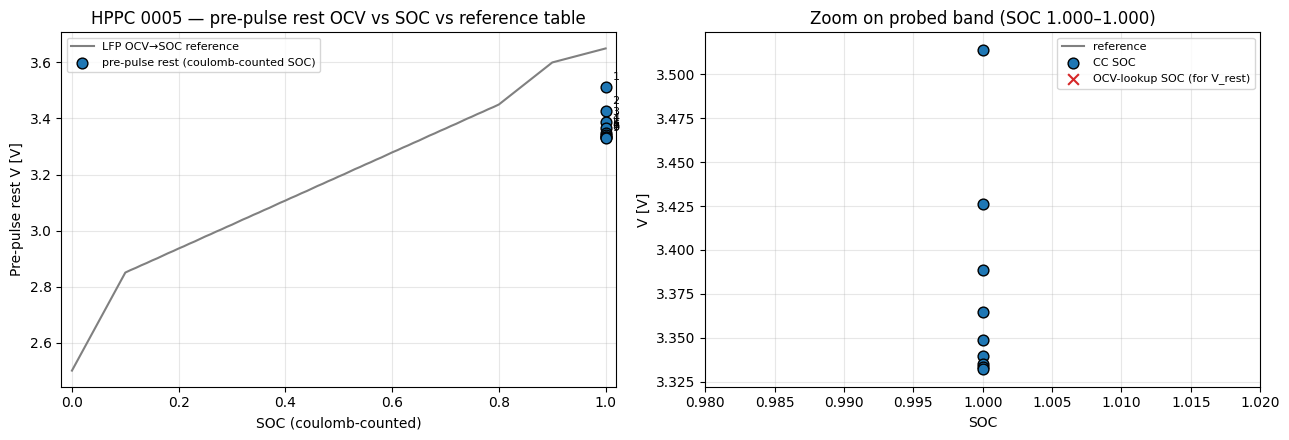


SOC_cc vs SOC_ocv: median diff = +0.3184, max |diff| = 0.3377
(Small diffs near the LFP plateau are expected — flat OCV → noisy OCV-lookup SOC.)


In [4]:
def hppc_pre_pulse_soc_v(cell_id: str = CELL_PROBE,
                        i_pulse_threshold_A: float = 45.0,
                        min_rest_s: float = 60.0,
                        rest_tail_s: float = 30.0):
    """For each high-current discharge pulse onset, get the (SOC, V) at the
    end of the immediately preceding rest. Returns a DataFrame.
    """
    df = load_test('HPPC', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    soc, meta = add_soc_axis_anchored(df, verbose=True)
    df['SOC'] = soc.values
    t = df['time'].to_numpy(dtype=float)
    I = df['current'].to_numpy(dtype=float)
    V = df['voltage'].to_numpy(dtype=float)

    # Mark high-current discharge samples (I < -threshold)
    is_pulse = I < -i_pulse_threshold_A
    # Pulse-onset = transition from rest/non-pulse to pulse
    onsets = np.where(np.diff(is_pulse.astype(int)) == 1)[0] + 1

    rows = []
    for k, idx in enumerate(onsets):
        # Walk back to find the end of the rest segment preceding this pulse
        j = idx - 1
        while j > 0 and abs(I[j]) > 0.5:
            j -= 1
        # Now j is the last sample of the preceding rest
        # Find rest start (back-walk while |I| < 0.5)
        j_start = j
        while j_start > 0 and abs(I[j_start - 1]) < 0.5:
            j_start -= 1
        rest_dur = t[j] - t[j_start]
        if rest_dur < min_rest_s:
            continue
        # Average voltage over the final rest_tail_s of the rest for noise rejection
        mask_tail = (t >= t[j] - rest_tail_s) & (t <= t[j])
        v_rest = float(V[mask_tail].mean()) if mask_tail.any() else float(V[j])
        rows.append({
            'pulse': k + 1,
            't_h': float(t[idx] / 3600.0),
            'rest_dur_s': float(rest_dur),
            'V_pre_rest_V': v_rest,
            'SOC_cc': float(df['SOC'].iloc[j]),
            'SOC_ocv': soc_from_ocv(v_rest),
        })
    return pd.DataFrame(rows), meta

pulses_df, meta = hppc_pre_pulse_soc_v(CELL_PROBE)
print(f'Found {len(pulses_df)} pulse-onset / pre-rest pairs for cell {CELL_PROBE}.\n')
print(pulses_df.to_string(index=False))

# ── Plot: SOC vs V_rest overlaid on the reference OCV-SOC curve ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(_SOC_FRAC, _OCV_V, '-', color='gray', lw=1.5, label='LFP OCV→SOC reference')
ax.scatter(pulses_df['SOC_cc'], pulses_df['V_pre_rest_V'], s=60,
            color='C0', edgecolor='k', zorder=5,
            label='pre-pulse rest (coulomb-counted SOC)')
for _, r in pulses_df.iterrows():
    ax.annotate(f'{int(r.pulse)}', (r.SOC_cc, r.V_pre_rest_V),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set(xlabel='SOC (coulomb-counted)', ylabel='Pre-pulse rest V [V]',
        title=f'HPPC {CELL_PROBE} — pre-pulse rest OCV vs SOC vs reference table')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)

# Zoom into the actual SOC band probed (top of charge)
ax = axes[1]
ax.plot(_SOC_FRAC, _OCV_V, '-', color='gray', lw=1.5, label='reference')
ax.scatter(pulses_df['SOC_cc'], pulses_df['V_pre_rest_V'], s=60,
            color='C0', edgecolor='k', zorder=5, label='CC SOC')
ax.scatter(pulses_df['SOC_ocv'], pulses_df['V_pre_rest_V'], s=60,
            color='C3', marker='x', zorder=5, label='OCV-lookup SOC (for V_rest)')
soc_min, soc_max = pulses_df['SOC_cc'].min(), pulses_df['SOC_cc'].max()
pad = 0.02
ax.set_xlim(soc_min - pad, soc_max + pad)
v_min = pulses_df['V_pre_rest_V'].min() - 0.01
v_max = pulses_df['V_pre_rest_V'].max() + 0.01
ax.set_ylim(v_min, v_max)
ax.set(xlabel='SOC', ylabel='V [V]', title=f'Zoom on probed band (SOC {soc_min:.3f}–{soc_max:.3f})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# ── Numeric agreement check ──
diff = (pulses_df['SOC_cc'] - pulses_df['SOC_ocv'])
print(f'\nSOC_cc vs SOC_ocv: median diff = {diff.median():+.4f}, max |diff| = {diff.abs().max():.4f}')
print('(Small diffs near the LFP plateau are expected — flat OCV → noisy OCV-lookup SOC.)')


## 2. Constant power raw signals

Plot V(t), I(t), instantaneous power P(t) = V·I, and the step-by-step segment annotations. We expect to see:

- 3 charge pulses at +180 W (V ramps up, current positive)
- 3 discharge pulses at -90 W (V ramps down, current negative)

If 270 W pulses really exist they should appear as a higher plateau on the power trace — we should be able to spot them by eye.

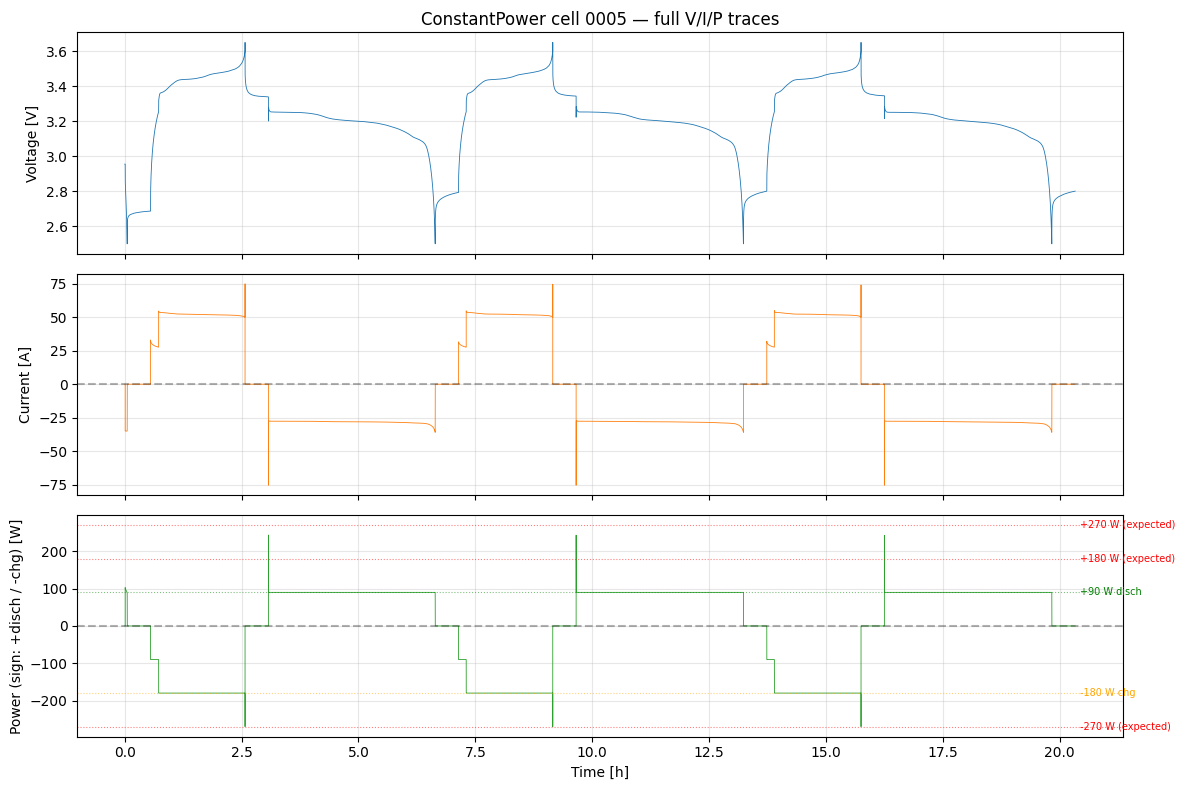

 seg    step   dur_s  P_median_W   V_range
   4  CP_Chg  7279.0      -180.0 2.72–3.65
   6 CP_DChg 12845.0        90.0 2.50–3.28
   8  CP_Chg  7256.0      -180.0 2.85–3.65
  10 CP_DChg 12887.0        90.0 2.50–3.29
  12  CP_Chg  7260.0      -180.0 2.80–3.65
  14 CP_DChg 12894.0        90.0 2.50–3.29


In [5]:
def plot_constant_power_full(cell_id: str):
    df = load_test('ConstantPower', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    t_h = df['time'].values / 3600.0
    P = (-df['voltage'].values * df['current'].values)  # +discharge, -charge convention
    # actually we want signed power: P_discharge = +, P_charge = -
    # current<0 on discharge → -V*I > 0 (good)
    # current>0 on charge → -V*I < 0 (good)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(t_h, df['voltage'].values, lw=0.6, color='C0')
    axes[0].set(ylabel='Voltage [V]',
                title=f'ConstantPower cell {cell_id} — full V/I/P traces')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_h, df['current'].values, lw=0.6, color='C1')
    axes[1].set(ylabel='Current [A]')
    axes[1].axhline(0, ls='--', color='black', alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(t_h, P, lw=0.6, color='C2')
    axes[2].set(ylabel='Power (sign: +disch / -chg) [W]', xlabel='Time [h]')
    axes[2].axhline(0, ls='--', color='black', alpha=0.3)
    # Annotate the canonical setpoints we'd expect to see if 90/180/270 W were all present
    for lvl, c, lbl in [(90, 'green', '+90 W disch'), (-180, 'orange', '-180 W chg'),
                         (180, 'red', '+180 W (expected)'),
                         (-270, 'red', '-270 W (expected)'),
                         (270, 'red', '+270 W (expected)')]:
        axes[2].axhline(lvl, ls=':', color=c, alpha=0.5, lw=0.8)
        axes[2].text(t_h[-1] * 1.005, lvl, lbl, fontsize=7, color=c,
                     verticalalignment='center')
    axes[2].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Numeric verification: median power per CP_DChg / CP_Chg segment
    df['_seg'] = (df['step_name'] != df['step_name'].shift()).cumsum()
    rows = []
    for sid, g in df.groupby('_seg'):
        if g['step_name'].iloc[0] not in ('CP_Chg', 'CP_DChg'):
            continue
        Pmed = (-g['voltage'] * g['current']).median()
        rows.append({'seg': sid, 'step': g['step_name'].iloc[0],
                     'dur_s': g['time'].iloc[-1] - g['time'].iloc[0],
                     'P_median_W': float(Pmed),
                     'V_range': f"{g['voltage'].min():.2f}–{g['voltage'].max():.2f}"})
    summ = pd.DataFrame(rows)
    print(summ.round({'P_median_W': 1, 'dur_s': 0}).to_string(index=False))

plot_constant_power_full(CELL_PROBE)

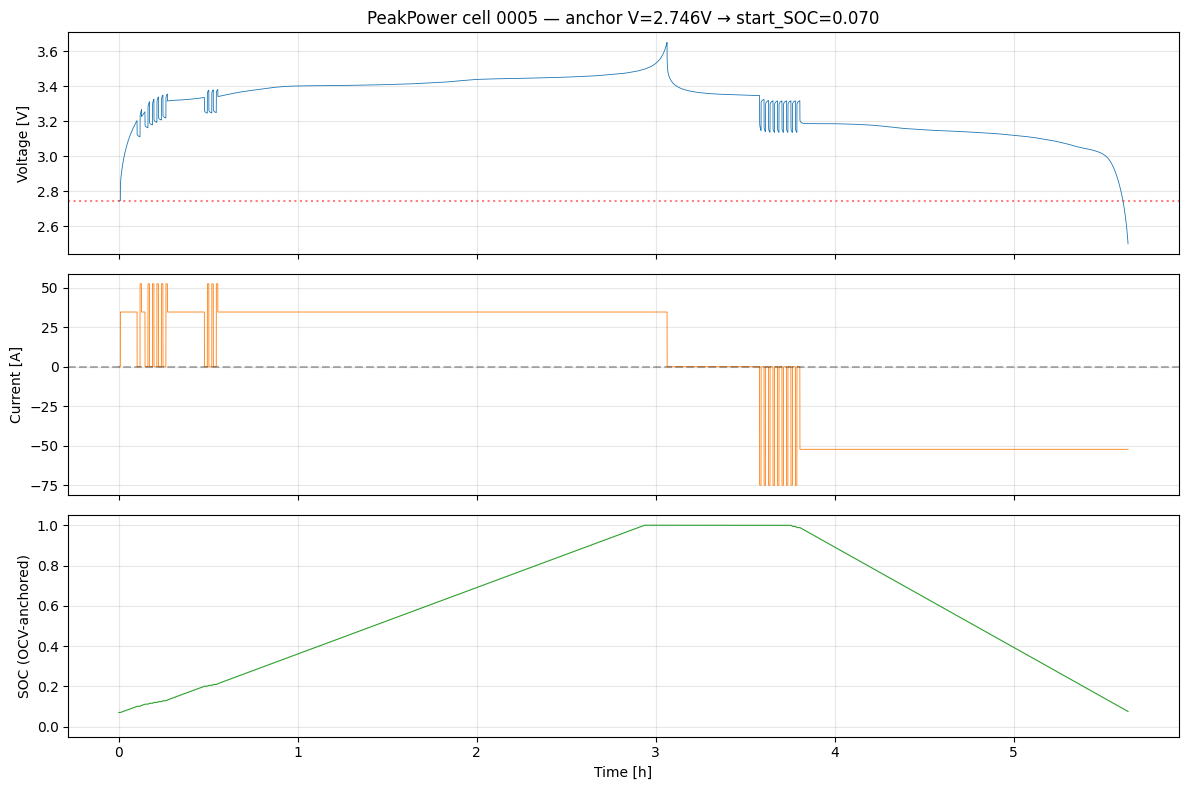

 seg  SOC_at_pulse  I_peak_A  P_peak_W  dur_s
  22         1.000      75.0     246.6   29.9
  24         1.000      75.0     243.0   30.0
  26         1.000      75.0     243.7   30.0
  28         1.000      75.0     241.4   30.6
  30         1.000      75.0     239.1   29.6
  32         1.000      75.0     246.8   29.6
  34         1.000      75.0     243.7   29.9
  36         1.000      75.0     240.5   30.0
  38         0.994      75.0     241.9   29.9
  SOC band covered by peak pulses: 0.994 → 1.000


In [6]:
def plot_peak_power_full(cell_id: str):
    df = load_test('PeakPower', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    soc, meta = add_soc_axis_anchored(df, verbose=False)
    t_h = df['time'].values / 3600.0

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(t_h, df['voltage'].values, lw=0.6, color='C0')
    axes[0].set(ylabel='Voltage [V]',
                title=f'PeakPower cell {cell_id} — anchor V={meta["anchor_voltage_V"]:.3f}V → start_SOC={meta["start_soc"]:.3f}')
    axes[0].axhline(meta['anchor_voltage_V'], ls=':', color='red', alpha=0.5)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_h, df['current'].values, lw=0.6, color='C1')
    axes[1].set(ylabel='Current [A]')
    axes[1].axhline(0, ls='--', color='black', alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(t_h, soc, lw=0.8, color='C2')
    axes[2].set(ylabel='SOC (OCV-anchored)', xlabel='Time [h]', ylim=(-0.05, 1.05))
    axes[2].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # SOC of each ≥60-A short discharge pulse
    df['SOC'] = soc.values
    df['_seg'] = (df['step_name'] != df['step_name'].shift()).cumsum()
    rows = []
    for sid, g in df.groupby('_seg'):
        if g['step_name'].iloc[0] != 'CC_DChg':
            continue
        if g['current'].abs().max() < 60:
            continue
        if (g['time'].iloc[-1] - g['time'].iloc[0]) > 60:
            continue
        rows.append({'seg': sid, 'SOC_at_pulse': float(g['SOC'].iloc[0]),
                     'I_peak_A': float(g['current'].abs().max()),
                     'P_peak_W': float((-g['voltage'] * g['current']).max()),
                     'dur_s': float(g['time'].iloc[-1] - g['time'].iloc[0])})
    summ = pd.DataFrame(rows)
    if not summ.empty:
        print(summ.round({'SOC_at_pulse':3,'I_peak_A':1,'P_peak_W':1,'dur_s':1}).to_string(index=False))
        print(f'  SOC band covered by peak pulses: {summ["SOC_at_pulse"].min():.3f} → {summ["SOC_at_pulse"].max():.3f}')

plot_peak_power_full(CELL_PROBE)

## 3. Peak power raw signals

Plot V(t), I(t), and SOC(t). We expect to see:

- An initial step-charge of the cell
- A series of short, high-current (~75 A) discharge pulses at successively lower SOC

If pulses really span every 10 % SOC from 100 % down to 10 %, the discharge spikes on the I(t) plot should be distributed across the entire 1.0 → 0.1 SOC range. If they cluster at the top, the stated full-SOC sweep is not actually in the data.

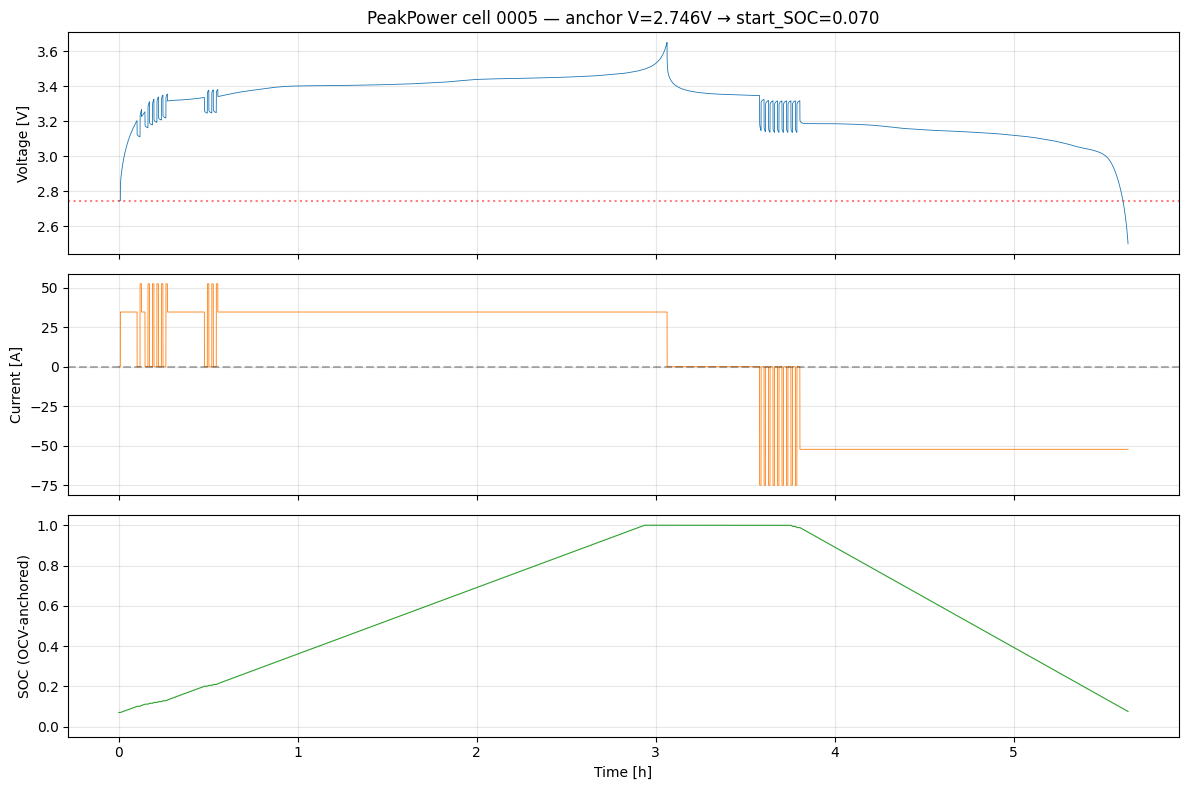

 seg  SOC_at_pulse  I_peak_A  P_peak_W  dur_s
  22         1.000      75.0     246.6   29.9
  24         1.000      75.0     243.0   30.0
  26         1.000      75.0     243.7   30.0
  28         1.000      75.0     241.4   30.6
  30         1.000      75.0     239.1   29.6
  32         1.000      75.0     246.8   29.6
  34         1.000      75.0     243.7   29.9
  36         1.000      75.0     240.5   30.0
  38         0.994      75.0     241.9   29.9
  SOC band covered by peak pulses: 0.994 → 1.000


In [7]:
def plot_peak_power_full(cell_id: str):
    df = load_test('PeakPower', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    soc, meta = add_soc_axis_anchored(df, verbose=False)
    t_h = df['time'].values / 3600.0

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(t_h, df['voltage'].values, lw=0.6, color='C0')
    axes[0].set(ylabel='Voltage [V]',
                title=f'PeakPower cell {cell_id} — anchor V={meta["anchor_voltage_V"]:.3f}V → start_SOC={meta["start_soc"]:.3f}')
    axes[0].axhline(meta['anchor_voltage_V'], ls=':', color='red', alpha=0.5)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_h, df['current'].values, lw=0.6, color='C1')
    axes[1].set(ylabel='Current [A]')
    axes[1].axhline(0, ls='--', color='black', alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(t_h, soc, lw=0.8, color='C2')
    axes[2].set(ylabel='SOC (OCV-anchored)', xlabel='Time [h]', ylim=(-0.05, 1.05))
    axes[2].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    df['SOC'] = soc.values
    df['_seg'] = (df['step_name'] != df['step_name'].shift()).cumsum()
    rows = []
    for sid, g in df.groupby('_seg'):
        if g['step_name'].iloc[0] != 'CC_DChg':
            continue
        if g['current'].abs().max() < 60:
            continue
        if (g['time'].iloc[-1] - g['time'].iloc[0]) > 60:
            continue
        rows.append({'seg': sid, 'SOC_at_pulse': float(g['SOC'].iloc[0]),
                     'I_peak_A': float(g['current'].abs().max()),
                     'P_peak_W': float((-g['voltage'] * g['current']).max()),
                     'dur_s': float(g['time'].iloc[-1] - g['time'].iloc[0])})
    summ = pd.DataFrame(rows)
    if not summ.empty:
        print(summ.round({'SOC_at_pulse':3,'I_peak_A':1,'P_peak_W':1,'dur_s':1}).to_string(index=False))
        print(f'  SOC band covered by peak pulses: {summ["SOC_at_pulse"].min():.3f} → {summ["SOC_at_pulse"].max():.3f}')

plot_peak_power_full(CELL_PROBE)

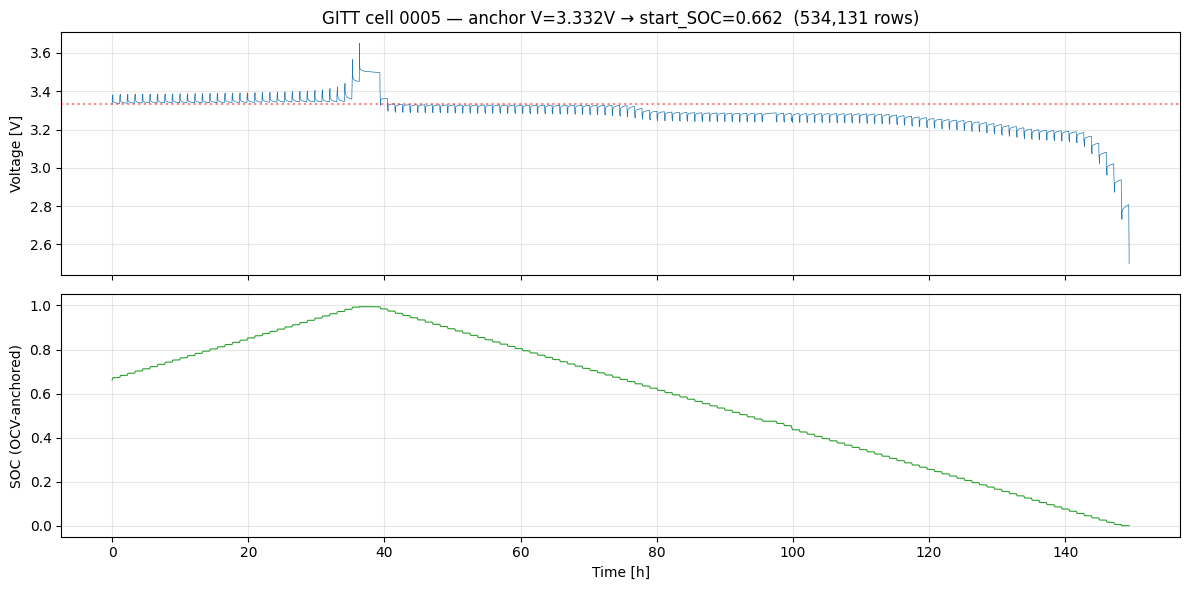

  SOC range: 0.000 → 0.995  (spans 99% of nominal capacity)
  n unique cycles in file: 133


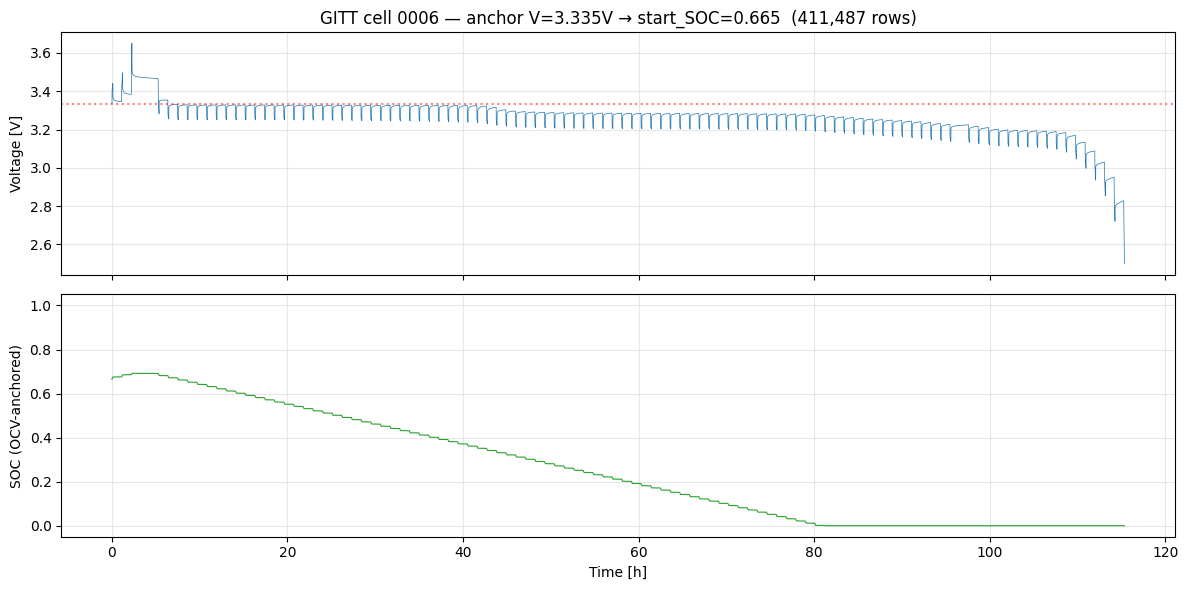

  SOC range: 0.000 → 0.692  (spans 69% of nominal capacity)
  n unique cycles in file: 102


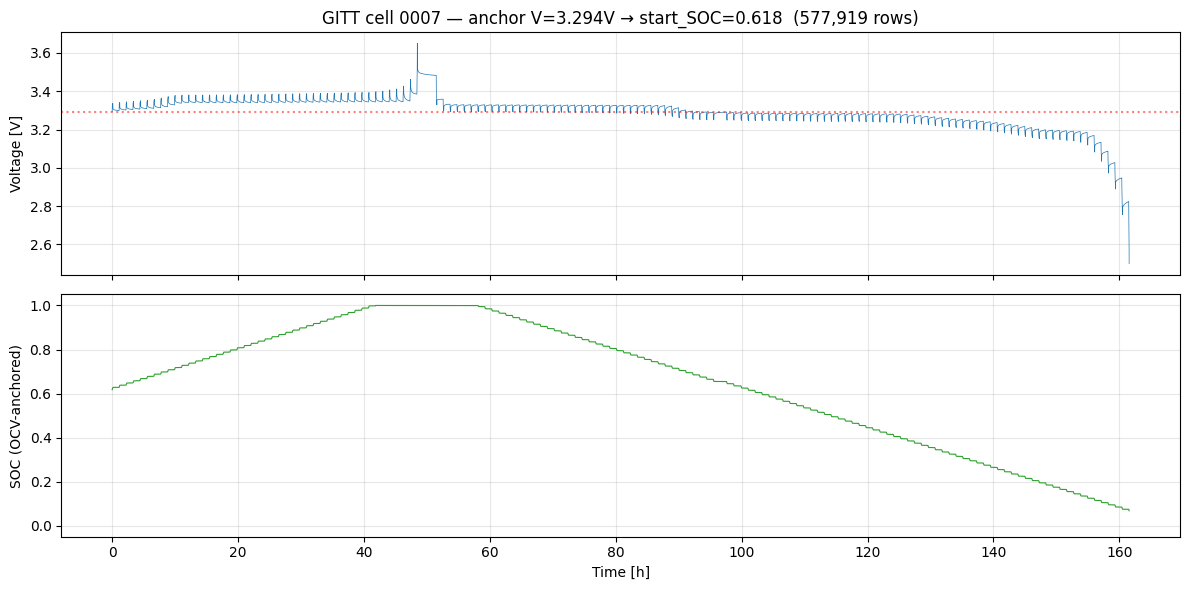

  SOC range: 0.068 → 1.000  (spans 93% of nominal capacity)
  n unique cycles in file: 144


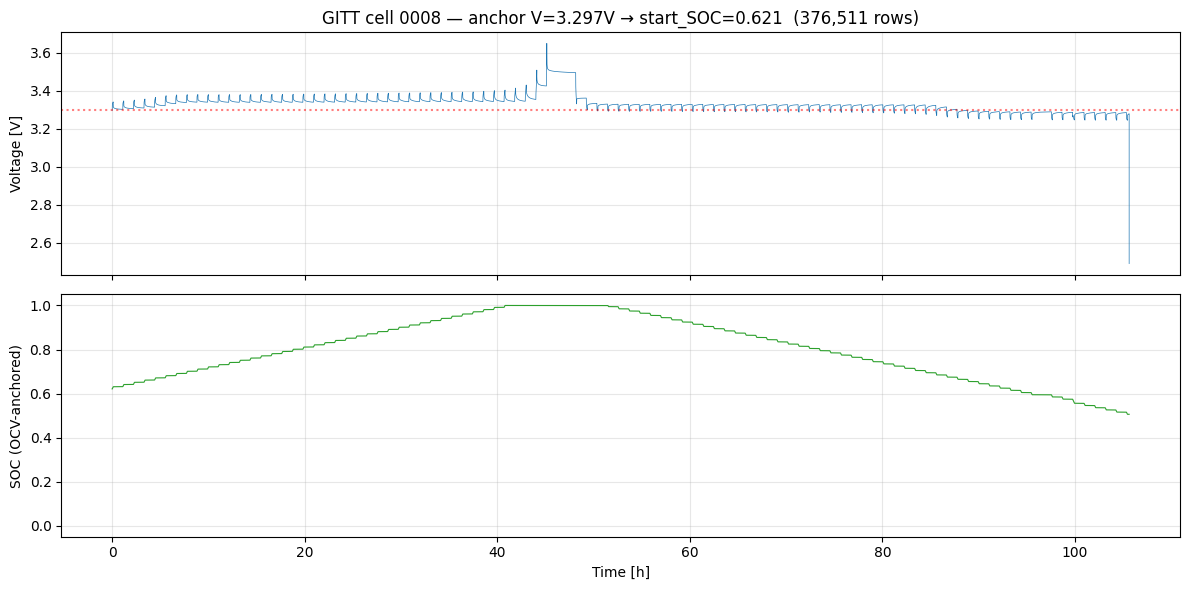

  SOC range: 0.506 → 1.000  (spans 49% of nominal capacity)
  n unique cycles in file: 93


In [8]:
def plot_gitt_full(cell_id: str):
    df = load_test('GITT', cell_id=cell_id).sort_values('time').reset_index(drop=True)
    soc, meta = add_soc_axis_anchored(df, verbose=False)
    t_h = df['time'].values / 3600.0
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t_h, df['voltage'].values, lw=0.5, color='C0')
    axes[0].set(ylabel='Voltage [V]',
                title=f'GITT cell {cell_id} — anchor V={meta["anchor_voltage_V"]:.3f}V → start_SOC={meta["start_soc"]:.3f}  ({len(df):,} rows)')
    axes[0].axhline(meta['anchor_voltage_V'], ls=':', color='red', alpha=0.5)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_h, soc, lw=0.8, color='C2')
    axes[1].set(ylabel='SOC (OCV-anchored)', xlabel='Time [h]', ylim=(-0.05, 1.05))
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    soc_min, soc_max = float(soc.min()), float(soc.max())
    print(f'  SOC range: {soc_min:.3f} → {soc_max:.3f}  (spans {int(100*(soc_max-soc_min))}% of nominal capacity)')
    print(f'  n unique cycles in file: {df["cycle"].nunique()}')

for cid in COHORT:
    plot_gitt_full(cid)

## 4. GITT SOC coverage per cell

Plot the GITT V(t) trace per cell with the coulomb-counted SOC overlay. The bottom of each figure shows the SOC range actually swept by the released file. Differences between cells (e.g. cell 0008 covers much less SOC than 0006) become obvious.

In [9]:
rows = []
for cid in COHORT:
    # HPPC
    df = load_test('HPPC', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    df['SOC'] = soc.values
    probe = df[df['current'].abs() > 45]
    hppc_band = (probe['SOC'].min(), probe['SOC'].max()) if not probe.empty else (None, None)

    # PeakPower
    df = load_test('PeakPower', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    df['SOC'] = soc.values
    df['_seg'] = (df['step_name'] != df['step_name'].shift()).cumsum()
    pp_socs = []
    for sid, g in df.groupby('_seg'):
        if g['step_name'].iloc[0] != 'CC_DChg':
            continue
        if g['current'].abs().max() < 60:
            continue
        if (g['time'].iloc[-1] - g['time'].iloc[0]) > 60:
            continue
        pp_socs.append(float(g['SOC'].iloc[0]))
    pp_band = (min(pp_socs), max(pp_socs)) if pp_socs else (None, None)

    # GITT
    df = load_test('GITT', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    gitt_band = (float(soc.min()), float(soc.max()))

    rows.append({
        'cell':                 cid,
        'HPPC probes SOC band': f"{hppc_band[0]:.3f}–{hppc_band[1]:.3f}" if hppc_band[0] is not None else '—',
        'PeakPower SOC band':   f"{pp_band[0]:.3f}–{pp_band[1]:.3f}" if pp_band[0] is not None else '—',
        'GITT SOC range':       f"{gitt_band[0]:.3f}–{gitt_band[1]:.3f}",
    })
summary = pd.DataFrame(rows).set_index('cell')
from IPython.display import Markdown, display
display(summary)
display(Markdown('\n**Stated test plans (per the report)**\n\n'
                  '- HPPC: pulses at every 10 % SOC interval (i.e. 0.10–1.00)\n'
                  '- PeakPower: pulses at every 10 % SOC interval (i.e. 0.10–1.00)\n'
                  '- GITT: ~1 % SOC pulses across the full SOC range\n\n'
                  '**Verify by eye in the V/I/P plots above.** Where the released-data SOC band is much '
                  'narrower than the stated plan, the data has been truncated upstream.'))

,HPPC probes SOC band,PeakPower SOC band,GITT SOC range
cell,,,
0005,1.000–1.000,0.994–1.000,0.000–0.995
0006,1.000–1.000,0.990–1.000,0.000–0.692
0007,1.000–1.000,0.994–1.000,0.068–1.000
0008,1.000–1.000,1.000–1.000,0.506–1.000



**Stated test plans (per the report)**

- HPPC: pulses at every 10 % SOC interval (i.e. 0.10–1.00)
- PeakPower: pulses at every 10 % SOC interval (i.e. 0.10–1.00)
- GITT: ~1 % SOC pulses across the full SOC range

**Verify by eye in the V/I/P plots above.** Where the released-data SOC band is much narrower than the stated plan, the data has been truncated upstream.

## 5. Side-by-side: probe SOC coverage vs stated test plan

Compact summary across all 4 cohort cells × 3 tests, showing the SOC range actually exercised.

In [10]:
rows = []
for cid in COHORT:
    # HPPC
    df = load_test('HPPC', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    df['SOC'] = soc.values
    probe = df[df['current'].abs() > 45]
    hppc_band = (probe['SOC'].min(), probe['SOC'].max()) if not probe.empty else (None, None)

    # PeakPower
    df = load_test('PeakPower', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    df['SOC'] = soc.values
    df['_seg'] = (df['step_name'] != df['step_name'].shift()).cumsum()
    pp_socs = []
    for sid, g in df.groupby('_seg'):
        if g['step_name'].iloc[0] != 'CC_DChg':
            continue
        if g['current'].abs().max() < 60:
            continue
        if (g['time'].iloc[-1] - g['time'].iloc[0]) > 60:
            continue
        pp_socs.append(float(g['SOC'].iloc[0]))
    pp_band = (min(pp_socs), max(pp_socs)) if pp_socs else (None, None)

    # GITT
    df = load_test('GITT', cell_id=cid).sort_values('time').reset_index(drop=True)
    soc, _ = add_soc_axis_anchored(df)
    gitt_band = (float(soc.min()), float(soc.max()))

    rows.append({
        'cell':                 cid,
        'HPPC probes SOC band': f"{hppc_band[0]:.3f}–{hppc_band[1]:.3f}" if hppc_band[0] is not None else '—',
        'PeakPower SOC band':   f"{pp_band[0]:.3f}–{pp_band[1]:.3f}" if pp_band[0] is not None else '—',
        'GITT SOC range':       f"{gitt_band[0]:.3f}–{gitt_band[1]:.3f}",
    })
summary = pd.DataFrame(rows).set_index('cell')
from IPython.display import Markdown, display
display(summary)
display(Markdown('\n**Stated test plans (per the report)**\n\n'
                  '- HPPC: pulses at every 10 % SOC interval (i.e. 0.10–1.00)\n'
                  '- PeakPower: pulses at every 10 % SOC interval (i.e. 0.10–1.00)\n'
                  '- GITT: ~1 % SOC pulses across the full SOC range\n\n'
                  '**Verify by eye in the V/I/P plots above.** Where the released-data SOC band is much '
                  'narrower than the stated plan, the data has been truncated upstream.'))

,HPPC probes SOC band,PeakPower SOC band,GITT SOC range
cell,,,
0005,1.000–1.000,0.994–1.000,0.000–0.995
0006,1.000–1.000,0.990–1.000,0.000–0.692
0007,1.000–1.000,0.994–1.000,0.068–1.000
0008,1.000–1.000,1.000–1.000,0.506–1.000



**Stated test plans (per the report)**

- HPPC: pulses at every 10 % SOC interval (i.e. 0.10–1.00)
- PeakPower: pulses at every 10 % SOC interval (i.e. 0.10–1.00)
- GITT: ~1 % SOC pulses across the full SOC range

**Verify by eye in the V/I/P plots above.** Where the released-data SOC band is much narrower than the stated plan, the data has been truncated upstream.